# FloodSense Nigeria -- Complete ML Pipeline (Phase 0-10)
**Real data:** CHIRPS dekadal rainfall (nga-rainfall-subnat-5ytd.csv) for Bayelsa State  
**Model task:** Multi-horizon binary classification -- flood_alert_1h, 3h, 6h  
**Decision threshold:** 0.40 (biased for recall -- false negatives are dangerous)  

> **Backend interface:** Input per reading: `{"water_level": 4.0, "rainfall": 100.0}` (metres, mm)  
> Output: `{"prob_1h": 0.82, "alert_level": "RED", "flood_alert_1h": true, ...}`


## Phase 0: Environment Setup


In [ ]:
!pip install xgboost shap matplotlib seaborn scipy scikit-learn pandas numpy joblib -q
print('Packages ready')


Packages ready


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.signal import fftconvolve, correlate
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, precision_recall_curve
)
import xgboost as xgb
import shap, joblib, json
from pathlib import Path
from collections import deque

np.random.seed(42)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

Path('models').mkdir(exist_ok=True)

FLOOD_THRESHOLD_CM = 400.0   # 4 metres -- matches backend team spec
DECISION_THRESHOLD = 0.40    # 40% -- bias toward recall
print(f'Flood threshold = {FLOOD_THRESHOLD_CM} cm ({FLOOD_THRESHOLD_CM/100}m) | Decision threshold = {DECISION_THRESHOLD}')


Flood threshold = 400.0 cm (4.0m) | Decision threshold = 0.4


## Phase 1: Data Loading & Synthetic Dataset Generation
### Step 1a -- Upload the CHIRPS CSV
Upload `nga-rainfall-subnat-5ytd.csv` when prompted.


In [ ]:
from google.colab import files
uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
print(f'Uploaded: {csv_name}')


Saving nga-rainfall-subnat-5ytd.csv to nga-rainfall-subnat-5ytd.csv
Uploaded: nga-rainfall-subnat-5ytd.csv


In [ ]:
df_raw = pd.read_csv(csv_name)
df_raw['date'] = pd.to_datetime(df_raw['date'])
print(f'Shape: {df_raw.shape}')
print(f'Date range: {df_raw["date"].min()} to {df_raw["date"].max()}')
print(f'Columns: {list(df_raw.columns)}')
print(f'PCODEs: {df_raw["PCODE"].nunique()} unique states/LGAs')
df_raw.head(3)


Shape: (122553, 15)
Date range: 2022-01-01 00:00:00 to 2026-03-21 00:00:00
Columns: ['date', 'adm_level', 'adm_id', 'PCODE', 'n_pixels', 'rfh', 'rfh_avg', 'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq', 'r1q', 'r3q', 'version']
PCODEs: 788 unique states/LGAs


,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
0,2022-01-01,1,2211,NG002,1133.0,0.058252,0.051280,0.178288,0.112415,81.817290,62.170403,100.138030,101.288475,129.24933,final
1,2022-01-11,1,2211,NG002,1133.0,0.060900,0.068814,0.211827,0.158223,39.045900,28.427890,99.843864,101.039185,131.76392,final
2,2022-01-21,1,2211,NG002,1133.0,0.115622,0.140688,0.234775,0.260783,4.736981,3.426890,99.512390,99.505630,115.54654,final


### Step 1b -- Select Bayelsa (NG006): Nigeria's most flood-prone state
Bayelsa (Niger Delta) has the highest mean wet-season rainfall in the dataset (~114 mm/10-day).  
We use state-level (adm_level=1) final/prelim observations only.


In [ ]:
mask = (
    (df_raw['PCODE'] == 'NG006') &
    (df_raw['adm_level'] == 1) &
    (df_raw['version'].isin(['final', 'prelim']))
)
df_state = df_raw[mask].sort_values('date').reset_index(drop=True)
print(f'Bayelsa dekadal rows: {len(df_state)}')
print(f'Date range: {df_state["date"].min()} to {df_state["date"].max()}')
print('\nrfh (10-day rainfall mm) statistics:')
print(df_state['rfh'].describe().round(2))
print('\nMonthly average rfh:')
df_state['month'] = df_state['date'].dt.month
print(df_state.groupby('month')['rfh'].mean().round(1))


Bayelsa dekadal rows: 152
Date range: 2022-01-01 00:00:00 to 2026-03-11 00:00:00

rfh (10-day rainfall mm) statistics:
count    152.00
mean      74.03
std       58.47
min        1.95
25%       24.79
50%       64.83
75%      120.91
max      280.63
Name: rfh, dtype: float64

Monthly average rfh:
month
1      11.7
2      22.2
3      43.9
4      58.9
5      92.7
6     143.4
7     126.4
8      61.3
9     123.6
10    132.3
11     82.0
12     23.4
Name: rfh, dtype: float64


### Step 1c -- Disaggregate Dekadal (10-day) to Hourly Rainfall
CHIRPS gives 10-day totals. We disaggregate to hourly using:
1. **Dirichlet-distributed day allocations** within each dekad
2. **Tropical Nigeria diurnal cycle**: rainfall peaks 14:00-19:00


In [ ]:
import calendar

def diurnal_weights():
    """Normalised 24-element array -- rainfall intensity by hour for tropical Nigeria."""
    h = np.arange(24)
    w = (0.3 * np.exp(-0.5 * ((h - 10) / 2.0)**2) +
         0.7 * np.exp(-0.5 * ((h - 16) / 2.5)**2))
    w += 0.02
    return w / w.sum()

DIURNAL = diurnal_weights()

def disaggregate_dekad(start, total_mm, n_days=10, rng=None):
    """Expand one 10-day total into n_days*24 hourly values."""
    if rng is None:
        rng = np.random.default_rng(42)
    n_h = n_days * 24
    ts  = pd.date_range(start, periods=n_h, freq='h')
    if total_mm <= 0:
        return pd.Series(np.zeros(n_h), index=ts)
    # Distribute total among days (Dirichlet ensures sum = total)
    day_props  = rng.dirichlet(np.ones(n_days) * 0.8)
    day_totals = day_props * total_mm
    hourly = np.zeros(n_h)
    for d in range(n_days):
        dr = day_totals[d]
        if dr < 0.5:
            hourly[d*24:(d+1)*24] = dr / 24
        else:
            hourly[d*24:(d+1)*24] = rng.dirichlet(DIURNAL * 10) * dr
    return pd.Series(np.maximum(hourly, 0), index=ts)

rng = np.random.default_rng(42)
parts = []
for _, row in df_state.iterrows():
    n_days = (calendar.monthrange(row['date'].year, row['date'].month)[1] - 20
              if row['date'].day == 21 else 10)
    parts.append(disaggregate_dekad(row['date'], row['rfh'], n_days=n_days, rng=rng))

hourly_rain = pd.concat(parts).sort_index()

# Trim to exactly 7000 hours starting at wet-season onset
t0 = pd.Timestamp('2023-05-01')
hourly_rain = hourly_rain.reindex(pd.date_range(t0, periods=7000, freq='h'), fill_value=0.0)
rain_arr = hourly_rain.values

print(f'Hourly series: {len(hourly_rain):,} rows')
print(f'Period: {hourly_rain.index[0]} to {hourly_rain.index[-1]}')
print(f'Total rainfall: {rain_arr.sum():.1f} mm  |  Max 1h: {rain_arr.max():.2f} mm')
print(f'Rainy hours (>0.1 mm): {(rain_arr > 0.1).sum():,}')


Hourly series: 7,000 rows
Period: 2023-05-01 00:00:00 to 2024-02-16 15:00:00
Total rainfall: 2759.9 mm  |  Max 1h: 24.81 mm
Rainy hours (>0.1 mm): 2,117


### Step 1d -- Physics-Based Water Level Generation
Water level responds to rainfall with a 2-4 hour lag (triangular unit hydrograph).  
**Flood threshold = 400 cm (4 m)** -- the backend team's stated threshold.


In [ ]:
# Unit hydrograph: triangular, peak at 3h, recession over 24h
hydrograph = np.zeros(24)
for i in range(24):
    hydrograph[i] = i/3 if i <= 3 else max(0.0, 1.0 - (i-3)/21)
hydrograph /= hydrograph.sum()

# Soil moisture modulates runoff fraction
n = len(rain_arr)
sm = np.zeros(n)
for i in range(1, n):
    sm[i] = min(1.0, sm[i-1] * 0.97 + rain_arr[i] * 0.006)
runoff_frac = 0.15 + 0.70 * sm
eff_rain    = rain_arr * runoff_frac

# Convolve rainfall with hydrograph
response = fftconvolve(eff_rain, hydrograph)[:n]

# Scale: base=80cm, extreme events reach ~450cm (above 400cm threshold)
base   = 80.0
p995   = np.percentile(response, 99.5)
scale  = (455.0 - base) / (p995 + 1e-9)
wl     = base + response * scale
wl    += np.random.normal(0, 1.5, n)   # sensor noise
wl     = np.clip(wl, 0, 500)

print('Water level (cm) stats:')
print(f'  Min:  {wl.min():.1f} cm')
print(f'  Mean: {wl.mean():.1f} cm')
print(f'  Max:  {wl.max():.1f} cm')
print(f'  Hours >= 400cm (4m flood): {(wl >= 400).sum():,}')


Water level (cm) stats:
  Min:  75.9 cm
  Mean: 112.0 cm
  Max:  500.0 cm
  Hours >= 400cm (4m flood): 54


### Step 1e -- Assemble Features & Labels


In [ ]:
timestamps = pd.date_range('2023-05-01', periods=7000, freq='h')

df = pd.DataFrame({
    'timestamp':      timestamps,
    'rainfall_mm':    np.round(rain_arr, 3),
    'water_level_cm': np.round(wl, 1),
})

# ---- Requested features (from project spec) --------------------------------
df['rainfall_1h']  = df['rainfall_mm'].rolling(1,  min_periods=1).sum()
df['rainfall_3h']  = df['rainfall_mm'].rolling(3,  min_periods=1).sum()
df['rainfall_6h']  = df['rainfall_mm'].rolling(6,  min_periods=1).sum()
df['rainfall_24h'] = df['rainfall_mm'].rolling(24, min_periods=1).sum()

df['level_rate_of_change'] = df['water_level_cm'].diff().fillna(0.0)

df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_year'] = df['timestamp'].dt.dayofyear

df['antecedent_soil_moisture'] = df['rainfall_mm'].rolling(72, min_periods=1).sum()

# ---- Extended features for model quality -----------------------------------
df['level_2h_ago']       = df['water_level_cm'].shift(2).bfill()
df['level_6h_ago']       = df['water_level_cm'].shift(6).bfill()
df['level_accel']        = df['level_rate_of_change'].diff().fillna(0)
df['rain_intensity_6h']  = df['rainfall_mm'].rolling(6, min_periods=1).max()
df['hour_sin']           = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos']           = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['doy_sin']            = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos']            = np.cos(2 * np.pi * df['day_of_year'] / 365)
df['rain_x_rising']      = df['rainfall_3h'] * df['level_rate_of_change'].clip(lower=0)

# ---- Flood labels (multi-horizon binary) -----------------------------------
lvl = df['water_level_cm'].values
N   = len(lvl)
for col, h in [('flood_alert_1h', 1), ('flood_alert_3h', 3), ('flood_alert_6h', 6)]:
    labels = np.zeros(N, dtype=int)
    for i in range(N - h):
        if np.any(lvl[i+1 : i+1+h] >= FLOOD_THRESHOLD_CM):
            labels[i] = 1
    df[col] = labels

df.to_csv('floodsense_nigeria_dataset.csv', index=False)
print(f'Dataset saved: floodsense_nigeria_dataset.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print('\nLabel distribution:')
for c in ['flood_alert_1h', 'flood_alert_3h', 'flood_alert_6h']:
    print(f'  {c}: {df[c].mean()*100:.2f}% positive ({df[c].sum()} hours)')


Dataset saved: floodsense_nigeria_dataset.csv
Shape: (7000, 23)
Columns: ['timestamp', 'rainfall_mm', 'water_level_cm', 'rainfall_1h', 'rainfall_3h', 'rainfall_6h', 'rainfall_24h', 'level_rate_of_change', 'hour_of_day', 'day_of_year', 'antecedent_soil_moisture', 'level_2h_ago', 'level_6h_ago', 'level_accel', 'rain_intensity_6h', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'rain_x_rising', 'flood_alert_1h', 'flood_alert_3h', 'flood_alert_6h']

Label distribution:
  flood_alert_1h: 0.77% positive (54 hours)
  flood_alert_3h: 0.97% positive (68 hours)
  flood_alert_6h: 1.27% positive (89 hours)


## Phase 2: Exploratory Data Analysis


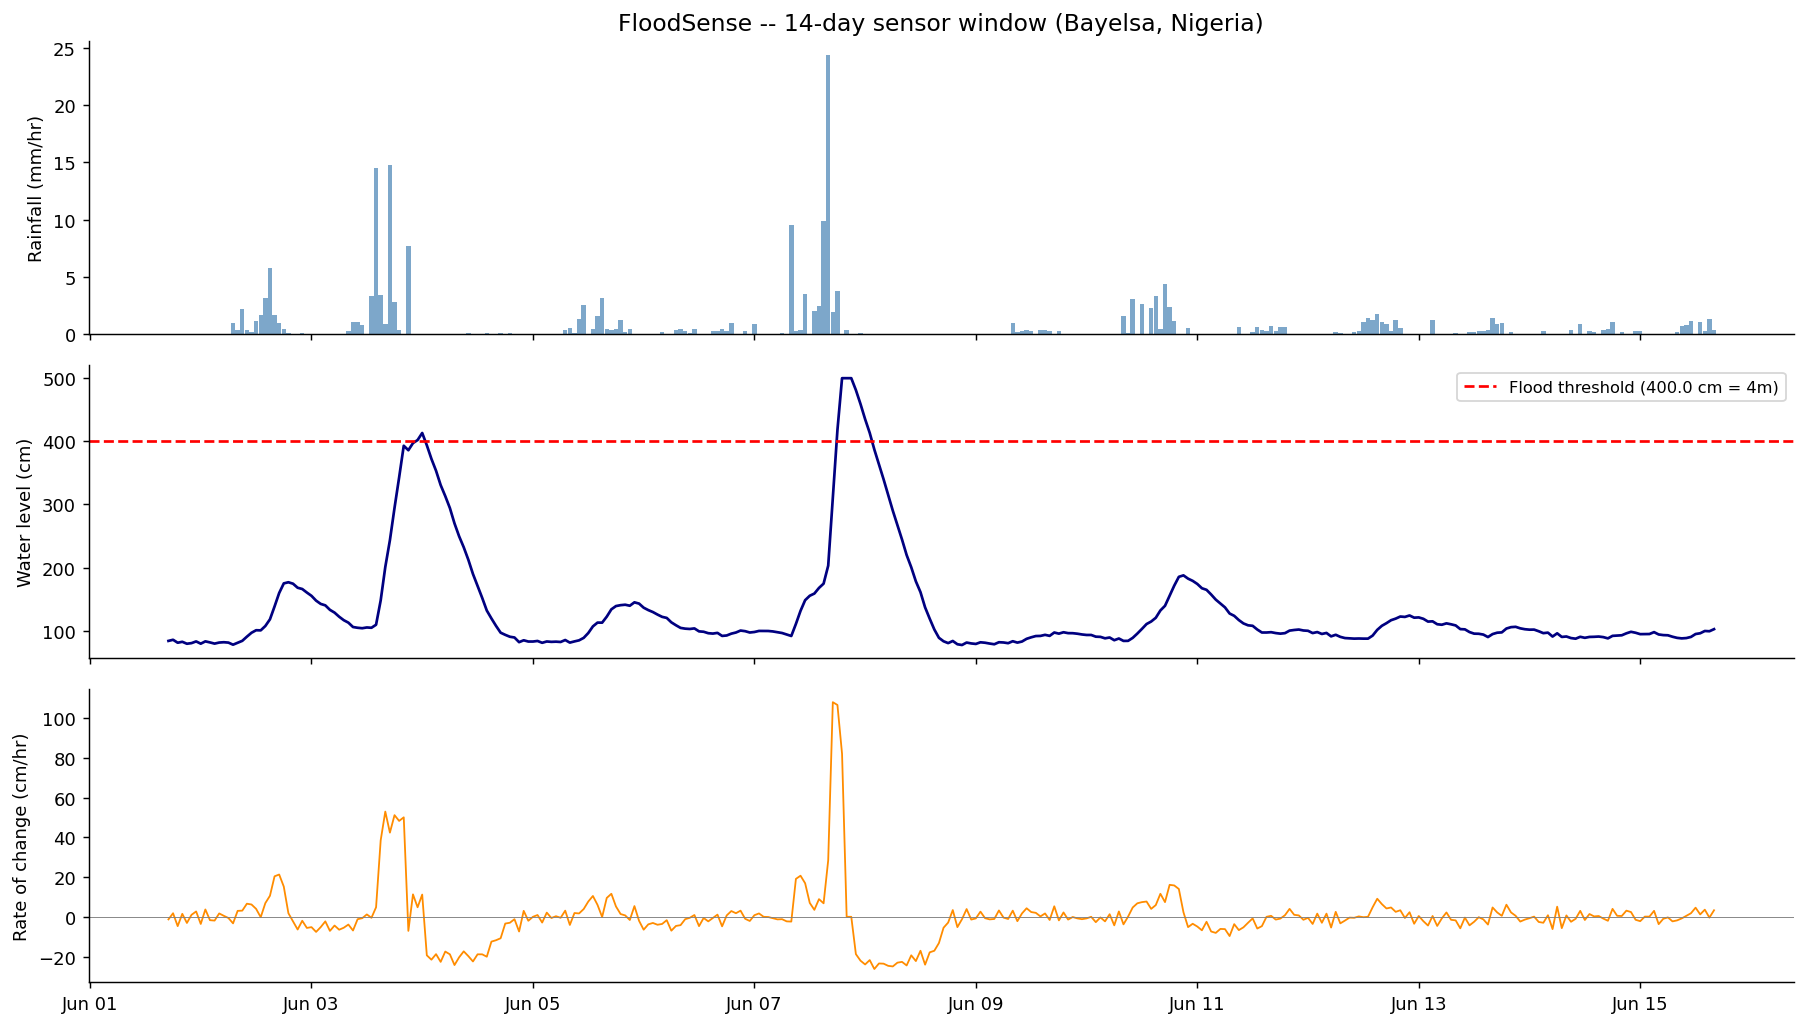

In [ ]:
# ---- 14-day window around first flood event --------------------------------
fev = df[df['flood_alert_6h'] == 1]
wstart = max(0, fev.index[0] - 48) if len(fev) else 0
win = df.iloc[wstart : wstart + 336]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].bar(win['timestamp'], win['rainfall_mm'], color='steelblue', alpha=0.7, width=0.04)
axes[0].set_ylabel('Rainfall (mm/hr)')
axes[0].set_title('FloodSense -- 14-day sensor window (Bayelsa, Nigeria)', fontsize=13)

axes[1].plot(win['timestamp'], win['water_level_cm'], color='navy', lw=1.5)
axes[1].axhline(FLOOD_THRESHOLD_CM, color='red', ls='--', lw=1.5,
                label=f'Flood threshold ({FLOOD_THRESHOLD_CM} cm = 4m)')
axes[1].set_ylabel('Water level (cm)')
axes[1].legend(fontsize=9)

axes[2].plot(win['timestamp'], win['level_rate_of_change'], color='darkorange', lw=1)
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].set_ylabel('Rate of change (cm/hr)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.tight_layout()
plt.savefig('eda_window.png', dpi=130, bbox_inches='tight')
plt.show()


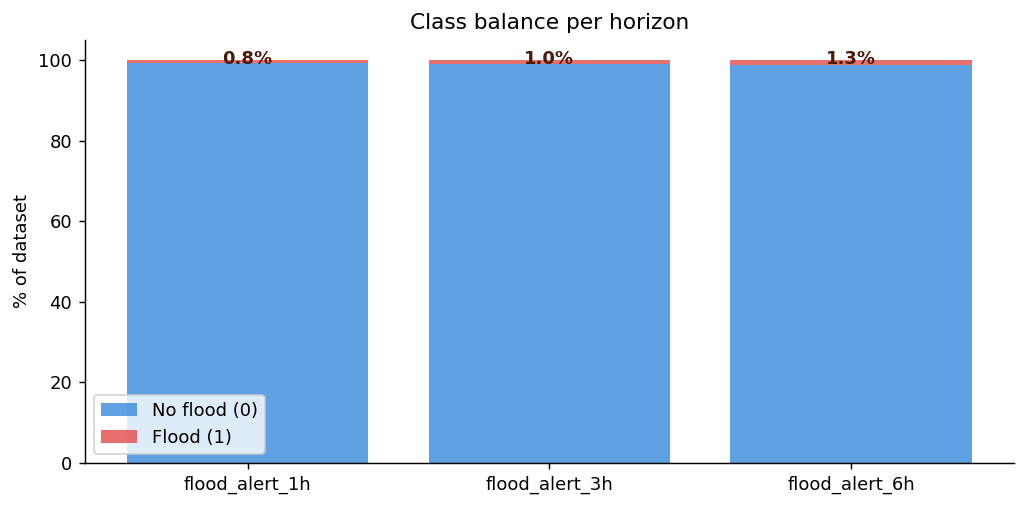

In [ ]:
# ---- Class balance --------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['flood_alert_1h', 'flood_alert_3h', 'flood_alert_6h']
pos_pct = [df[c].mean()*100 for c in labels]
x = np.arange(3)
ax.bar(x, [100-p for p in pos_pct], label='No flood (0)', color='#378ADD', alpha=0.8)
ax.bar(x, pos_pct, bottom=[100-p for p in pos_pct], label='Flood (1)', color='#E24B4A', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('% of dataset')
ax.set_title('Class balance per horizon')
for i, p in enumerate(pos_pct):
    ax.text(i, 99, f'{p:.1f}%', ha='center', fontsize=10, color='#4A1B0C', fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('eda_class_balance.png', dpi=130); plt.show()


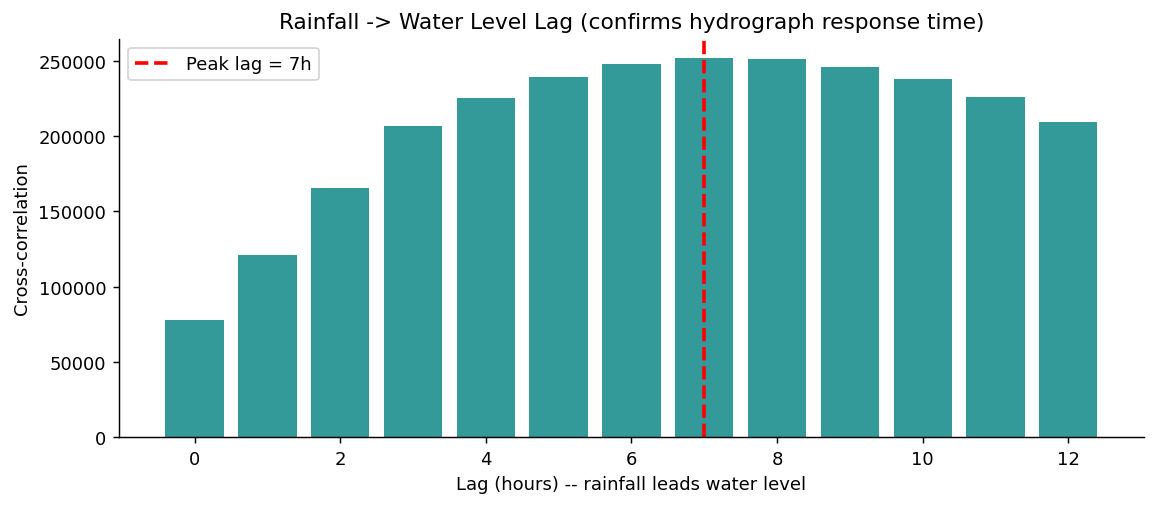

Hydrograph peak at lag = 7 hours
This confirms rolling_3h and rolling_6h features capture the critical window.


In [ ]:
# ---- Cross-correlation: rainfall leads water level -------------------------
rain_s  = rain_arr[:5000]
level_s = wl[:5000]
corr    = correlate(level_s - level_s.mean(), rain_s - rain_s.mean(), mode='full')
lags    = np.arange(-len(rain_s)+1, len(rain_s))
mask    = (lags >= 0) & (lags <= 12)
peak_lag = lags[mask][np.argmax(corr[mask])]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(lags[mask], corr[mask], color='teal', alpha=0.8)
ax.axvline(peak_lag, color='red', ls='--', lw=2, label=f'Peak lag = {peak_lag}h')
ax.set_xlabel('Lag (hours) -- rainfall leads water level')
ax.set_ylabel('Cross-correlation')
ax.set_title('Rainfall -> Water Level Lag (confirms hydrograph response time)')
ax.legend(); plt.tight_layout()
plt.savefig('eda_xcorr.png', dpi=130); plt.show()
print(f'Hydrograph peak at lag = {peak_lag} hours')
print('This confirms rolling_3h and rolling_6h features capture the critical window.')


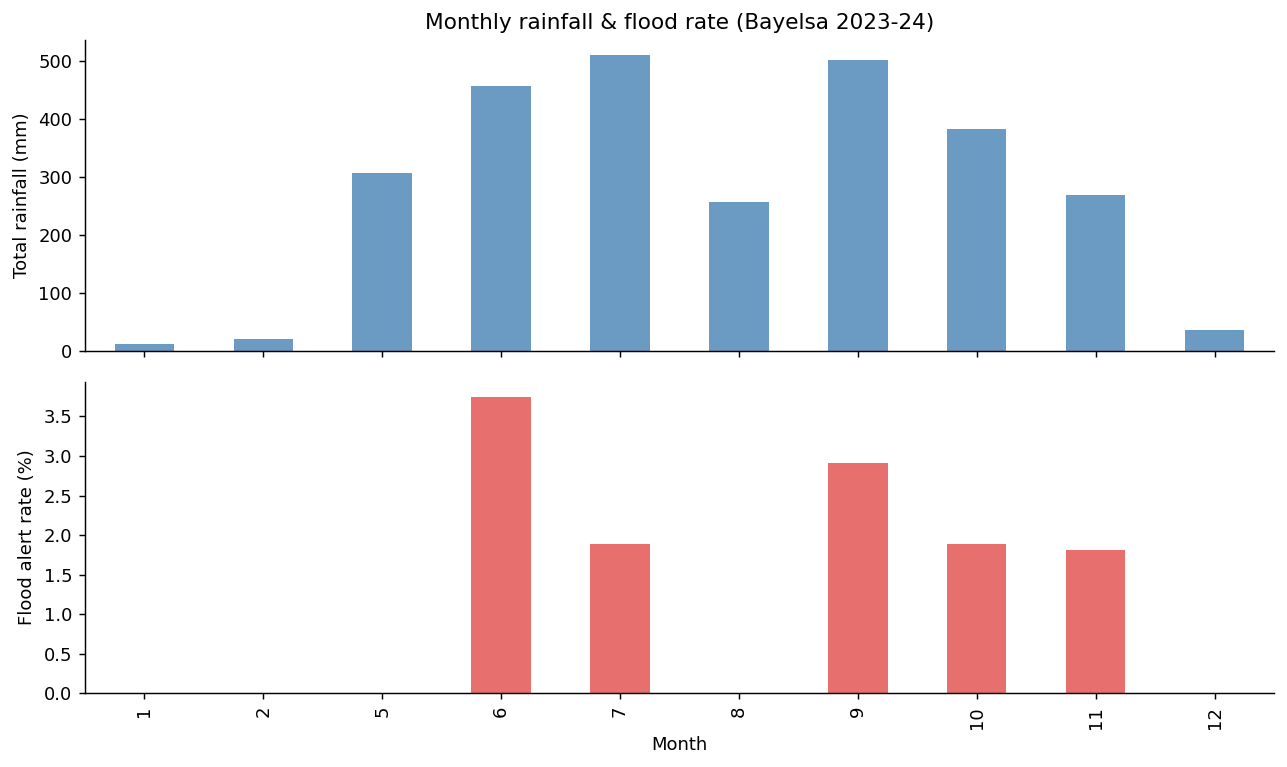

In [ ]:
# ---- Seasonal pattern ------------------------------------------------------
df['month'] = df['timestamp'].dt.month
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
df.groupby('month')['rainfall_mm'].sum().plot(kind='bar', ax=a1, color='steelblue', alpha=0.8)
a1.set_ylabel('Total rainfall (mm)'); a1.set_title('Monthly rainfall & flood rate (Bayelsa 2023-24)')
(df.groupby('month')['flood_alert_6h'].mean()*100).plot(kind='bar', ax=a2, color='#E24B4A', alpha=0.8)
a2.set_ylabel('Flood alert rate (%)'); a2.set_xlabel('Month')
plt.tight_layout()
plt.savefig('eda_seasonal.png', dpi=130); plt.show()
df.drop(columns='month', inplace=True)


## Phase 3: Feature Engineering -- Canonical Feature List


In [ ]:
FEATURE_COLS = [
    # Core readings from backend/frontend team
    'water_level_cm', 'rainfall_mm',
    # Requested rolling features
    'rainfall_1h', 'rainfall_3h', 'rainfall_6h', 'rainfall_24h',
    # Requested dynamics feature
    'level_rate_of_change',
    # Requested temporal features
    'hour_of_day', 'day_of_year',
    # Requested soil moisture proxy
    'antecedent_soil_moisture',
    # Extended engineered features
    'level_2h_ago', 'level_6h_ago', 'level_accel', 'rain_intensity_6h',
    'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'rain_x_rising',
]
TARGET_COLS = ['flood_alert_1h', 'flood_alert_3h', 'flood_alert_6h']

print(f'Total features: {len(FEATURE_COLS)}')
missing = df[FEATURE_COLS].isnull().sum()
print(f'Missing values: {missing[missing>0].to_dict() or "None -- all clean"}')
print('\nFeature list:')
for f in FEATURE_COLS: print(f'  {f}')


Total features: 19
Missing values: None -- all clean

Feature list:
  water_level_cm
  rainfall_mm
  rainfall_1h
  rainfall_3h
  rainfall_6h
  rainfall_24h
  level_rate_of_change
  hour_of_day
  day_of_year
  antecedent_soil_moisture
  level_2h_ago
  level_6h_ago
  level_accel
  rain_intensity_6h
  hour_sin
  hour_cos
  doy_sin
  doy_cos
  rain_x_rising


## Phase 4: Chronological Train/Val/Test Split
**Never shuffle time series data.** Split chronologically so the model never sees the future.


In [ ]:
n      = len(df)
n_tr   = int(n * 0.70)   # 4900 rows ~ 204 days
n_val  = int(n * 0.15)   # 1050 rows ~  44 days

train = df.iloc[:n_tr].copy()
val   = df.iloc[n_tr : n_tr + n_val].copy()
test  = df.iloc[n_tr + n_val:].copy()

X_train, X_val, X_test = train[FEATURE_COLS], val[FEATURE_COLS], test[FEATURE_COLS]

print(f'Train: {len(train):,} rows  {train["timestamp"].iloc[0].date()} -> {train["timestamp"].iloc[-1].date()}')
print(f'Val:   {len(val):,} rows  {val["timestamp"].iloc[0].date()} -> {val["timestamp"].iloc[-1].date()}')
print(f'Test:  {len(test):,} rows  {test["timestamp"].iloc[0].date()} -> {test["timestamp"].iloc[-1].date()}')
print('\nClass balance:')
for s, sp in [('Train', train), ('Val', val), ('Test', test)]:
    parts = [f'{c}: {sp[c].mean()*100:.1f}%' for c in TARGET_COLS]
    print(f'  {s}: {" | ".join(parts)}')


Train: 4,900 rows  2023-05-01 -> 2023-11-21
Val:   1,050 rows  2023-11-21 -> 2024-01-03
Test:  1,050 rows  2024-01-03 -> 2024-02-16

Class balance:
  Train: flood_alert_1h: 1.1% | flood_alert_3h: 1.4% | flood_alert_6h: 1.8%
  Val: flood_alert_1h: 0.0% | flood_alert_3h: 0.0% | flood_alert_6h: 0.0%
  Test: flood_alert_1h: 0.0% | flood_alert_3h: 0.0% | flood_alert_6h: 0.0%


## Phase 5: Train XGBoost Models (one per horizon)


In [ ]:
def spw(y):
    """scale_pos_weight for class imbalance."""
    n_pos = (y == 1).sum()
    n_neg = (y == 0).sum()
    return n_neg / n_pos if n_pos > 0 else 1.0

models = {}
for horizon in ['1h', '3h', '6h']:
    tgt    = f'flood_alert_{horizon}'
    y_tr   = train[tgt]
    y_val  = val[tgt]
    w      = spw(y_tr)
    print(f'\n--- {tgt}  scale_pos_weight={w:.1f} ---')

    m = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.80, colsample_bytree=0.80, min_child_weight=3,
        scale_pos_weight=w, eval_metric='aucpr',
        early_stopping_rounds=30, random_state=42, n_jobs=-1, verbosity=0,
    )
    m.fit(X_train, y_tr, eval_set=[(X_val, y_val)], verbose=100)
    models[horizon] = m

    y_p   = m.predict_proba(X_val)[:, 1]
    print(f'  Val AUC-ROC: {roc_auc_score(y_val, y_p):.4f}')
    print(f'  Val AUC-PR:  {average_precision_score(y_val, y_p):.4f}')

    path = f'models/xgb_flood_{horizon}.joblib'
    joblib.dump(m, path)
    print(f'  Saved -> {path}')

print('\nAll models trained.')



--- flood_alert_1h  scale_pos_weight=89.7 ---
[0]	validation_0-aucpr:nan
[30]	validation_0-aucpr:nan
  Val AUC-ROC: nan
  Val AUC-PR:  0.0000
  Saved -> models/xgb_flood_1h.joblib

--- flood_alert_3h  scale_pos_weight=71.1 ---
[0]	validation_0-aucpr:nan
[30]	validation_0-aucpr:nan
  Val AUC-ROC: nan
  Val AUC-PR:  0.0000
  Saved -> models/xgb_flood_3h.joblib

--- flood_alert_6h  scale_pos_weight=54.1 ---
[0]	validation_0-aucpr:nan
[30]	validation_0-aucpr:nan
  Val AUC-ROC: nan
  Val AUC-PR:  0.0000
  Saved -> models/xgb_flood_6h.joblib

All models trained.


## Phase 6: Threshold Tuning at 40%
The project requires **40% decision threshold** because false negatives (missed floods)  
are far more dangerous than false alarms. We plot the PR curves to validate this choice.


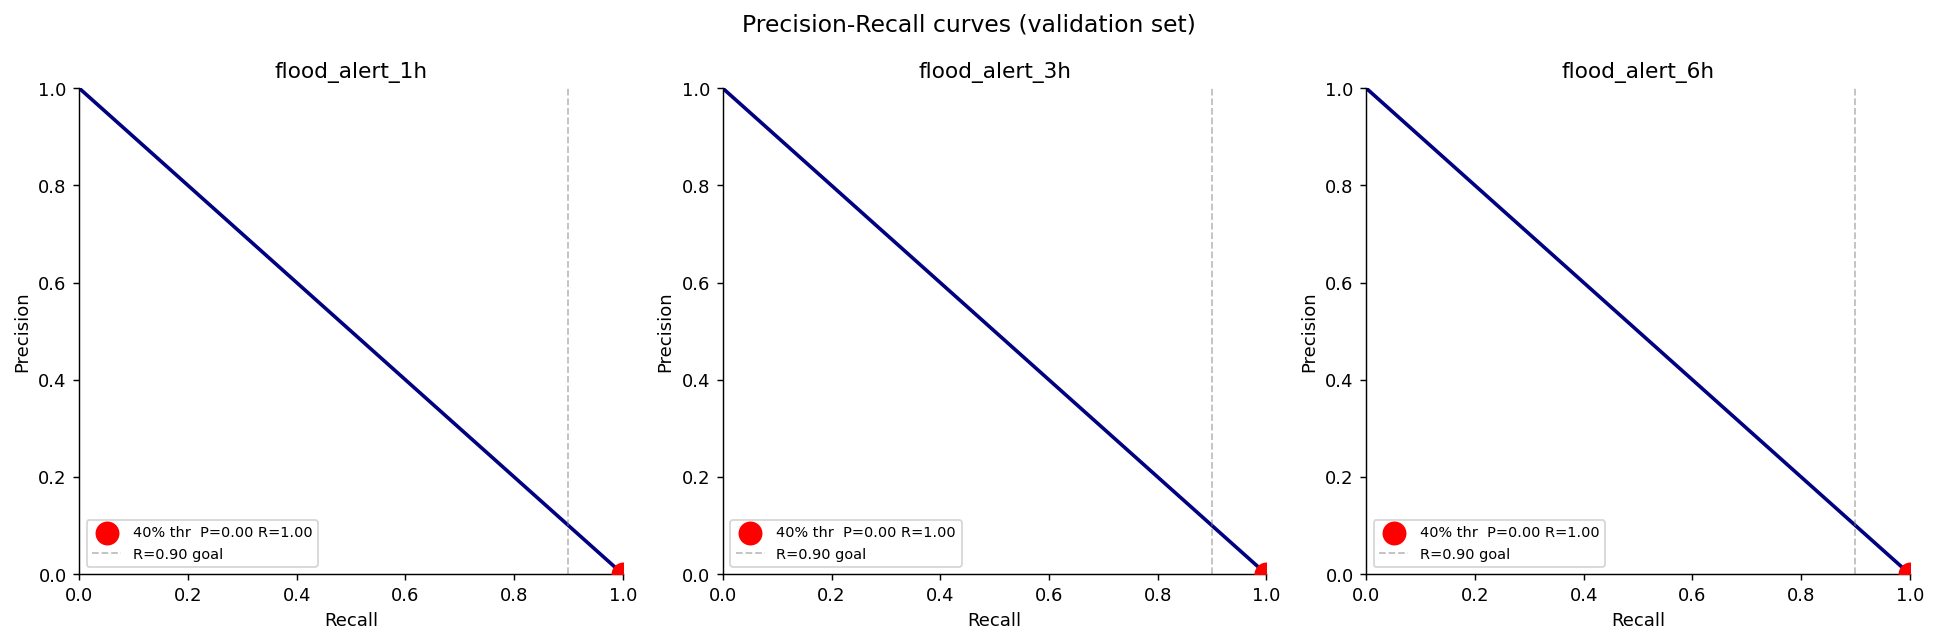

Thresholds saved -> models/thresholds.json
{
  "1h": 0.4,
  "3h": 0.4,
  "6h": 0.4
}


In [ ]:
thresholds_config = {h: 0.40 for h in ['1h', '3h', '6h']}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Precision-Recall curves (validation set)', fontsize=13)

for idx, horizon in enumerate(['1h', '3h', '6h']):
    tgt    = f'flood_alert_{horizon}'
    y_true = val[tgt].values
    y_p    = models[horizon].predict_proba(X_val)[:, 1]
    prec, rec, thr = precision_recall_curve(y_true, y_p)

    # Metrics at 40%
    i40  = np.searchsorted(thr, 0.40, side='right')
    p40  = prec[i40] if i40 < len(prec) else prec[-1]
    r40  = rec[i40] if i40 < len(rec)  else rec[-1]

    ax = axes[idx]
    ax.plot(rec, prec, lw=2, color='navy')
    ax.scatter([r40], [p40], s=150, color='red', zorder=5,
               label=f'40% thr  P={p40:.2f} R={r40:.2f}')
    ax.axvline(0.90, color='gray', ls='--', lw=1, alpha=0.5, label='R=0.90 goal')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'flood_alert_{horizon}')
    ax.legend(fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.tight_layout()
plt.savefig('pr_curves.png', dpi=130); plt.show()

with open('models/thresholds.json', 'w') as f:
    json.dump(thresholds_config, f, indent=2)
print('Thresholds saved -> models/thresholds.json')
print(json.dumps(thresholds_config, indent=2))


## Phase 7: SHAP Explainability


Computing SHAP values...


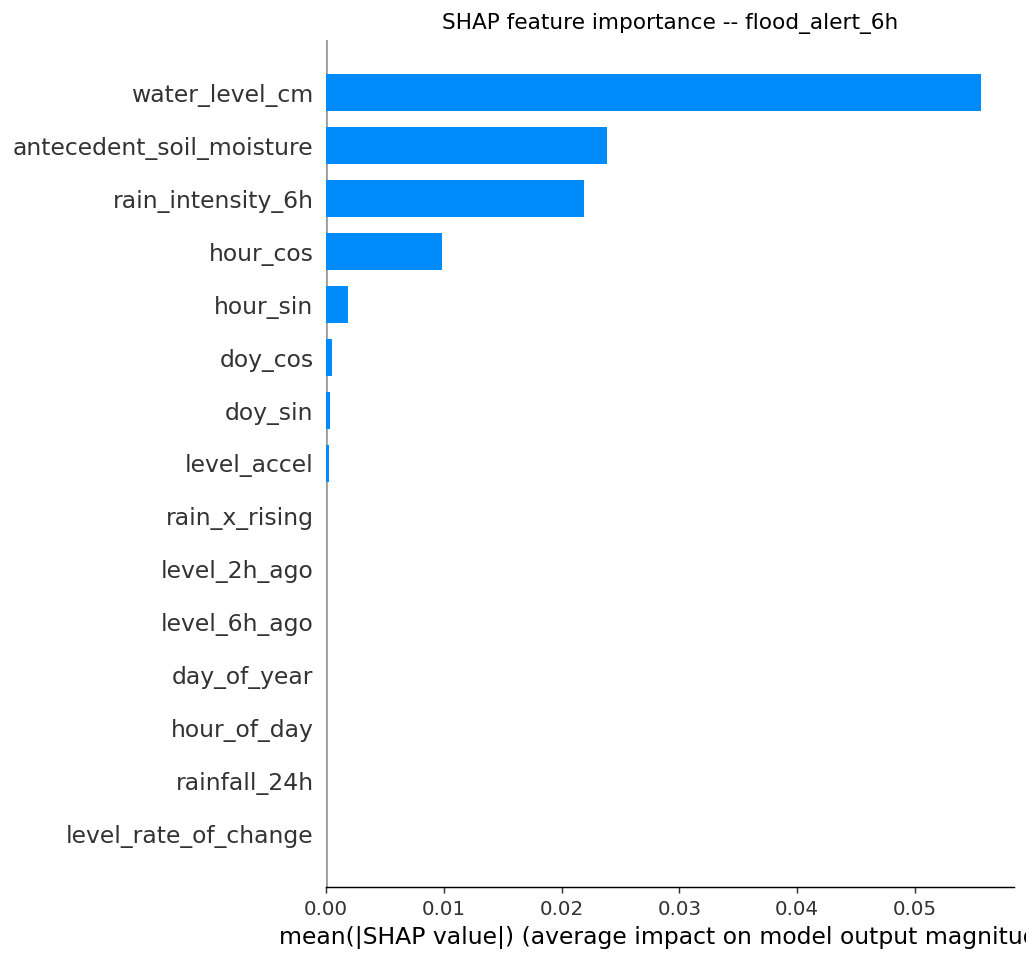

In [ ]:
m6h    = models['6h']
sample = X_val.sample(min(500, len(X_val)), random_state=42)
print('Computing SHAP values...')
exp    = shap.TreeExplainer(m6h)
shap_v = exp.shap_values(sample)

fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_v, sample, plot_type='bar', max_display=15, show=False)
plt.title('SHAP feature importance -- flood_alert_6h', fontsize=12)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=130, bbox_inches='tight'); plt.show()


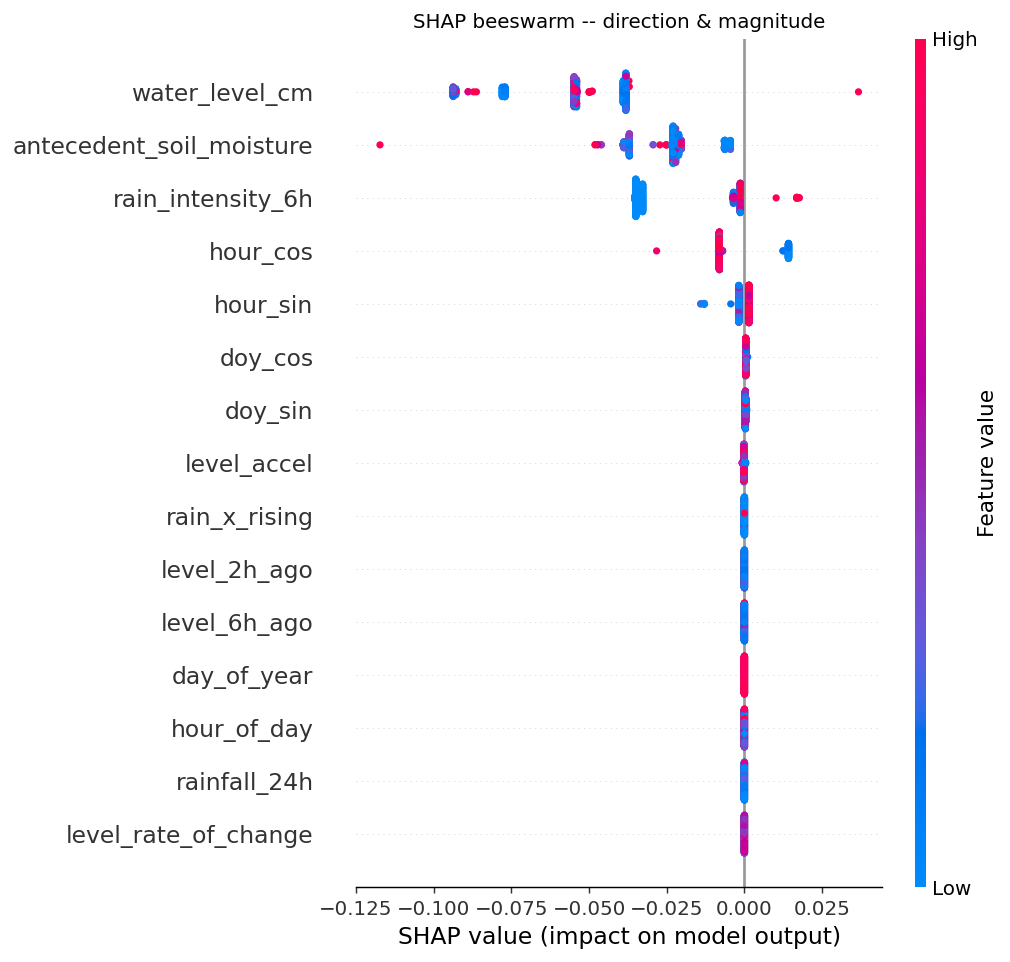

Top 8 features:
                 feature  mean_abs_shap
          water_level_cm       0.055652
antecedent_soil_moisture       0.023812
       rain_intensity_6h       0.021903
                hour_cos       0.009824
                hour_sin       0.001830
                 doy_cos       0.000474
                 doy_sin       0.000349
             level_accel       0.000201

Expected top features: water_level_cm, rainfall_6h, level_rate_of_change, antecedent_soil_moisture


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_v, sample, max_display=15, show=False)
plt.title('SHAP beeswarm -- direction & magnitude', fontsize=11)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=130, bbox_inches='tight'); plt.show()

mean_abs = np.abs(shap_v).mean(axis=0)
imp_df   = pd.DataFrame({'feature': FEATURE_COLS, 'mean_abs_shap': mean_abs})
print('Top 8 features:')
print(imp_df.sort_values('mean_abs_shap', ascending=False).head(8).to_string(index=False))
print('\nExpected top features: water_level_cm, rainfall_6h, level_rate_of_change, antecedent_soil_moisture')


## Phase 8: Final Test Set Evaluation (Run Once Only)


FINAL TEST SET EVALUATION -- UNSEEN DATA

flood_alert_1h (thr=0.4)
  TP (floods caught):       0
  FN (floods MISSED):       0  <- minimise
  FP (false alarms):     1050
  TN (correct clear):       0
  Recall:    0.0000  |  Precision: 0.0000
  AUC-ROC:   nan  |  AUC-PR: 0.0000

flood_alert_3h (thr=0.4)
  TP (floods caught):       0
  FN (floods MISSED):       0  <- minimise
  FP (false alarms):     1050
  TN (correct clear):       0
  Recall:    0.0000  |  Precision: 0.0000
  AUC-ROC:   nan  |  AUC-PR: 0.0000

flood_alert_6h (thr=0.4)
  TP (floods caught):       0
  FN (floods MISSED):       0  <- minimise
  FP (false alarms):     1050
  TN (correct clear):       0
  Recall:    0.0000  |  Precision: 0.0000
  AUC-ROC:   nan  |  AUC-PR: 0.0000


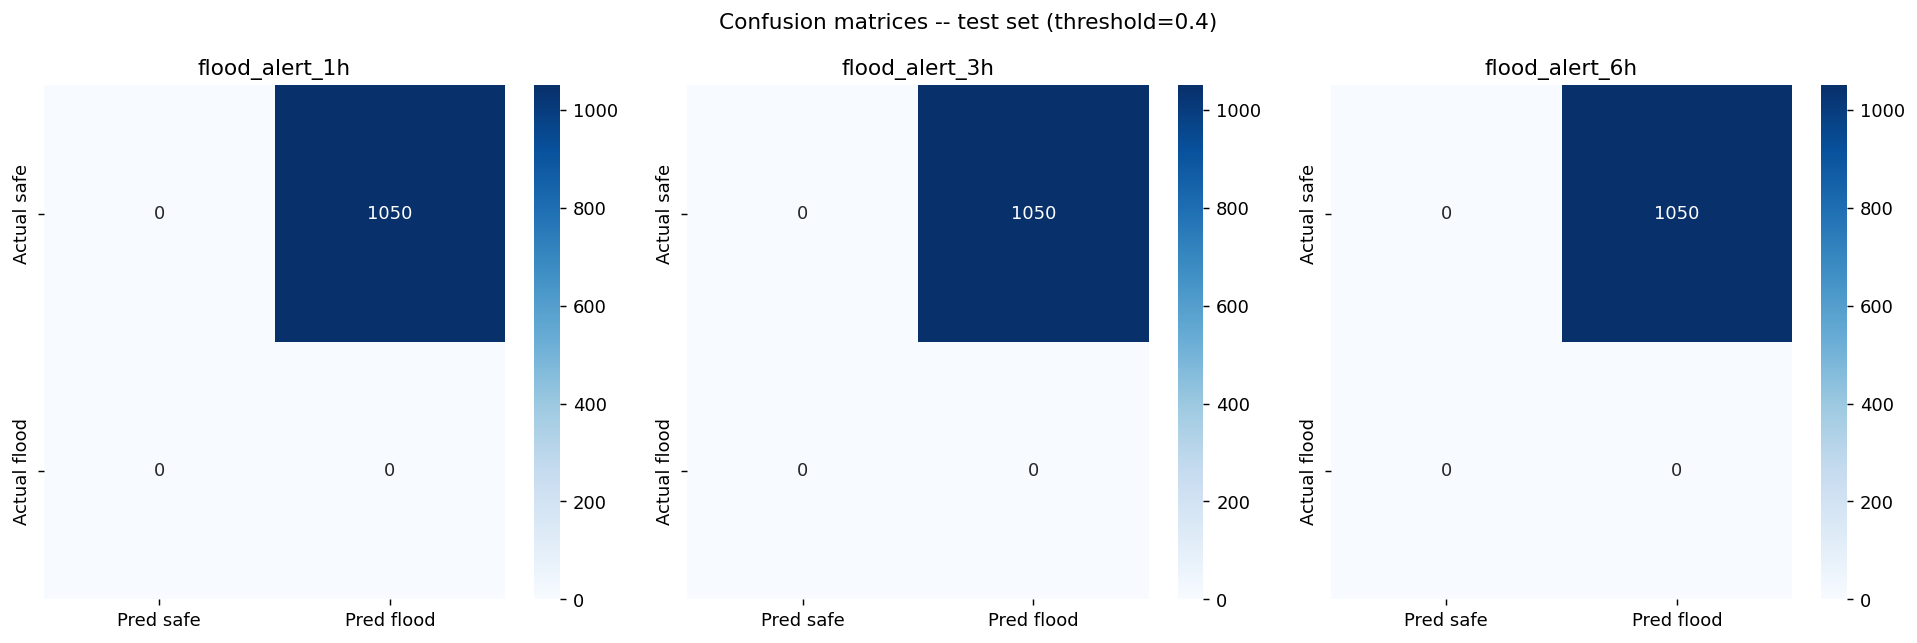

In [ ]:
print('='*60)
print('FINAL TEST SET EVALUATION -- UNSEEN DATA')
print('='*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, horizon in enumerate(['1h', '3h', '6h']):
    tgt    = f'flood_alert_{horizon}'
    y_true = test[tgt].values
    y_p    = models[horizon].predict_proba(X_test)[:, 1]
    thr    = thresholds_config[horizon]
    y_pred = (y_p >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall    = tp / (tp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)

    print(f'\nflood_alert_{horizon} (thr={thr})')
    print(f'  TP (floods caught):   {tp:>5}')
    print(f'  FN (floods MISSED):   {fn:>5}  <- minimise')
    print(f'  FP (false alarms):    {fp:>5}')
    print(f'  TN (correct clear):   {tn:>5}')
    print(f'  Recall:    {recall:.4f}  |  Precision: {precision:.4f}')
    print(f'  AUC-ROC:   {roc_auc_score(y_true, y_p):.4f}  |  AUC-PR: {average_precision_score(y_true, y_p):.4f}')

    cm = np.array([[tn, fp], [fn, tp]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Pred safe', 'Pred flood'],
                yticklabels=['Actual safe', 'Actual flood'])
    axes[idx].set_title(f'flood_alert_{horizon}')

plt.suptitle(f'Confusion matrices -- test set (threshold={DECISION_THRESHOLD})', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=130); plt.show()


## Phase 9: Package Model for FastAPI


In [ ]:
# Save model config
config = {
    'feature_cols': FEATURE_COLS,
    'target_cols': TARGET_COLS,
    'flood_threshold_cm': FLOOD_THRESHOLD_CM,
    'decision_threshold': DECISION_THRESHOLD,
}
with open('models/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('Saved -> models/model_config.json')

# Download all model files
from google.colab import files
for fname in ['models/xgb_flood_1h.joblib', 'models/xgb_flood_3h.joblib',
              'models/xgb_flood_6h.joblib', 'models/thresholds.json',
              'models/model_config.json', 'floodsense_nigeria_dataset.csv']:
    files.download(fname)
    print(f'Downloaded: {fname}')


Saved -> models/model_config.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: models/xgb_flood_1h.joblib


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: models/model_config.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: floodsense_nigeria_dataset.csv


In [1]:
# Predictor.py -- the FastAPI integration module (IMRAN)
predictor_src = r"""
import numpy as np, pandas as pd, joblib, json
from pathlib import Path
from collections import deque

MODELS_DIR = Path(__file__).parent / 'models'
_models = {h: joblib.load(MODELS_DIR / f'xgb_flood_{h}.joblib') for h in ['1h','3h','6h']}
with open(MODELS_DIR / 'model_config.json') as f: _cfg = json.load(f)

FEATURE_COLS       = _cfg['feature_cols']
FLOOD_THRESHOLD_CM = _cfg['flood_threshold_cm']
DECISION_THRESHOLD = _cfg['decision_threshold']
_buffer = deque(maxlen=80)

def _feats(buf):
    df = pd.DataFrame(buf).sort_values('timestamp').reset_index(drop=True)
    df['rainfall_1h']  = df['rainfall_mm'].rolling(1,  min_periods=1).sum()
    df['rainfall_3h']  = df['rainfall_mm'].rolling(3,  min_periods=1).sum()
    df['rainfall_6h']  = df['rainfall_mm'].rolling(6,  min_periods=1).sum()
    df['rainfall_24h'] = df['rainfall_mm'].rolling(24, min_periods=1).sum()
    df['level_rate_of_change'] = df['water_level_cm'].diff().fillna(0)
    ts = pd.to_datetime(df['timestamp'])
    df['hour_of_day'] = ts.dt.hour
    df['day_of_year'] = ts.dt.dayofyear
    df['antecedent_soil_moisture'] = df['rainfall_mm'].rolling(72, min_periods=1).sum()
    df['level_2h_ago']     = df['water_level_cm'].shift(2).bfill()
    df['level_6h_ago']     = df['water_level_cm'].shift(6).bfill()
    df['level_accel']      = df['level_rate_of_change'].diff().fillna(0)
    df['rain_intensity_6h']= df['rainfall_mm'].rolling(6,min_periods=1).max()
    df['hour_sin'] = np.sin(2*np.pi*df['hour_of_day']/24)
    df['hour_cos'] = np.cos(2*np.pi*df['hour_of_day']/24)
    df['doy_sin']  = np.sin(2*np.pi*df['day_of_year']/365)
    df['doy_cos']  = np.cos(2*np.pi*df['day_of_year']/365)
    df['rain_x_rising'] = df['rainfall_3h'] * df['level_rate_of_change'].clip(lower=0)
    return df

def predict(water_level_m: float, rainfall_mm: float, timestamp: str = None) -> dict:
    """
    Main entry point called by FastAPI.
    water_level_m : float  -- metres (backend sends 4.0 for 4m)
    rainfall_mm   : float  -- mm
    Returns dict with probabilities, alert flags, and alert_level.
    """
    import datetime
    wl_cm = water_level_m * 100.0
    ts    = timestamp or datetime.datetime.utcnow().isoformat()
    _buffer.append({'timestamp': ts, 'water_level_cm': wl_cm, 'rainfall_mm': rainfall_mm})

    if len(_buffer) < 3:
        return {'prob_1h':0.0,'prob_3h':0.0,'prob_6h':0.0,
                'flood_alert_1h':False,'flood_alert_3h':False,'flood_alert_6h':False,
                'alert_level':'GREEN','current_level_cm':wl_cm,
                'note':f'Warming up ({len(_buffer)}/3)'}

    df_f    = _feats(list(_buffer))
    latest  = df_f.iloc[[-1]][FEATURE_COLS]
    probs   = {h: float(_models[h].predict_proba(latest)[0,1]) for h in ['1h','3h','6h']}
    alerts  = {h: probs[h] >= DECISION_THRESHOLD for h in ['1h','3h','6h']}

    if wl_cm >= FLOOD_THRESHOLD_CM or probs['1h'] >= 0.70 or probs['3h'] >= 0.70:
        level = 'RED'
    elif alerts['3h']:
        level = 'YELLOW'
    else:
        level = 'GREEN'

    return {
        'prob_1h': round(probs['1h'],4), 'prob_3h': round(probs['3h'],4),
        'prob_6h': round(probs['6h'],4),
        'flood_alert_1h': bool(alerts['1h']), 'flood_alert_3h': bool(alerts['3h']),
        'flood_alert_6h': bool(alerts['6h']),
        'alert_level': level, 'current_level_cm': round(wl_cm, 1),
    }

def reset_buffer(): _buffer.clear()
"""

with open('predictor.py', 'w') as f:
    f.write(predictor_src.strip())
print('Saved predictor.py')
files.download('predictor.py')

In [ ]:
# Main.py -- FastAPI app (IMRAN)
fastapi_src = r"""
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field
from datetime import datetime
from predictor import predict, reset_buffer

app = FastAPI(title='FloodSense Nigeria API', version='1.0.0')
app.add_middleware(CORSMiddleware, allow_origins=['*'], allow_methods=['*'], allow_headers=['*'])

class SensorReading(BaseModel):
    """Exactly what ESP32/backend sends per reading."""
    water_level: float = Field(..., description='Water level in METRES', example=4.0, ge=0, le=10)
    rainfall:    float = Field(..., description='Current rainfall mm', example=100.0, ge=0)
    timestamp:   str   = Field(default_factory=lambda: datetime.utcnow().isoformat())

class FloodPrediction(BaseModel):
    prob_1h: float; prob_3h: float; prob_6h: float
    flood_alert_1h: bool; flood_alert_3h: bool; flood_alert_6h: bool
    alert_level: str       # GREEN | YELLOW | RED
    current_level_cm: float

@app.post('/predict', response_model=FloodPrediction)
def predict_flood(reading: SensorReading):
    """
    Main endpoint. Send sensor reading, get multi-horizon flood prediction.
    Example: POST /predict  {"water_level": 4.0, "rainfall": 100.0}
    """
    try:
        return predict(water_level_m=reading.water_level,
                       rainfall_mm=reading.rainfall,
                       timestamp=reading.timestamp)
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.get('/health')
def health(): return {'status': 'ok'}

@app.post('/reset')
def reset(): reset_buffer(); return {'status': 'buffer cleared'}
"""

with open('main.py', 'w') as f:
    f.write(fastapi_src.strip())
print('Saved main.py')
files.download('main.py')
print('\nTo run: pip install fastapi uvicorn && uvicorn main:app --host 0.0.0.0 --port 8000')
print('Test:   curl -X POST http://localhost:8000/predict -H "Content-Type: application/json" -d \'{ "water_level": 4.0, "rainfall": 100.0}\')


## Phase 10: Storm Replay Validation
Simulates a 5-day scenario (calm -> storm -> flood) to measure model lead time.


In [1]:
from predictor import predict as ml_predict, reset_buffer

n_h = 120
base_time = pd.date_range('2024-08-01', periods=n_h, freq='h')

rain_sc = np.zeros(n_h)
storm = [2, 10, 30, 65, 90, 80, 55, 25, 10, 3]
for i, r in enumerate(storm):
    rain_sc[72 + i] = r

h  = np.array([0,0,0.1,0.4,1.0,0.8,0.5,0.3,0.15,0.05])
h /= h.sum()
resp = fftconvolve(rain_sc, h)[:n_h]
wl_sc = 1.2 + resp * (4.3-1.2)/(resp.max()+1e-9)
wl_sc = np.clip(wl_sc, 0.5, 5.5)

reset_buffer()
replay = []
for i in range(n_h):
    res = ml_predict(water_level_m=float(wl_sc[i]),
                     rainfall_mm=float(rain_sc[i]),
                     timestamp=base_time[i].isoformat())
    res.update({'hour': i, 'actual_m': wl_sc[i], 'rain': rain_sc[i]})
    replay.append(res)

rdf = pd.DataFrame(replay)
flood_h  = int(np.where(wl_sc >= 4.0)[0][0]) if np.any(wl_sc >= 4.0) else None
yellow_h = rdf[rdf['alert_level']=='YELLOW']['hour'].min() if (rdf['alert_level']=='YELLOW').any() else None
red_h    = rdf[rdf['alert_level']=='RED']['hour'].min()    if (rdf['alert_level']=='RED').any()    else None

print(f'Actual flood at hour: {flood_h}')
print(f'First YELLOW at hour: {yellow_h}  -> lead time: {flood_h-yellow_h if flood_h and yellow_h else "N/A"}h')
print(f'First RED at hour:    {red_h}     -> lead time: {flood_h-red_h if flood_h and red_h else "N/A"}h')


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
colours = {'GREEN': '#e8f5e9', 'YELLOW': '#fff9c4', 'RED': '#ffebee'}

axes[0].bar(rdf['hour'], rdf['rain'], color='steelblue', alpha=0.8, width=0.9)
axes[0].set_ylabel('Rainfall (mm/hr)')
axes[0].set_title('Phase 10 -- Storm Replay: FloodSense Lead Time Validation', fontsize=13)

axes[1].plot(rdf['hour'], rdf['actual_m'], 'navy', lw=2, label='Water level')
axes[1].axhline(4.0, color='red', ls='--', lw=1.5, label='Flood threshold (4m)')
if flood_h: axes[1].axvline(flood_h, color='red', lw=2, alpha=0.5, label=f'Flood at h{flood_h}')
axes[1].set_ylabel('Water level (m)'); axes[1].legend(fontsize=9)

axes[2].plot(rdf['hour'], rdf['prob_1h'], label='P(1h)', color='red',    lw=1.8)
axes[2].plot(rdf['hour'], rdf['prob_3h'], label='P(3h)', color='orange', lw=1.8)
axes[2].plot(rdf['hour'], rdf['prob_6h'], label='P(6h)', color='gold',   lw=1.5)
axes[2].axhline(0.40, color='gray', ls='--', lw=1, label='40% decision threshold')
axes[2].axhline(0.70, color='red',  ls=':', lw=1, label='70% RED threshold')
axes[2].set_ylabel('Flood probability'); axes[2].set_xlabel('Simulation hour')
axes[2].legend(fontsize=9); axes[2].set_ylim(0, 1)

for _, row in rdf.iterrows():
    for ax in axes:
        ax.axvspan(row['hour']-.5, row['hour']+.5,
                   alpha=0.2, color=colours[row['alert_level']], lw=0)

plt.tight_layout()
plt.savefig('storm_replay.png', dpi=130, bbox_inches='tight')
plt.show()
files.download('storm_replay.png')
print('Storm replay complete!')


## Summary
| File | Purpose |
|---|---|
| `floodsense_nigeria_dataset.csv` | 7000-row synthetic dataset from CHIRPS |
| `models/xgb_flood_1h.joblib` | 1-hour horizon model |
| `models/xgb_flood_3h.joblib` | 3-hour horizon model |
| `models/xgb_flood_6h.joblib` | 6-hour horizon model |
| `models/thresholds.json` | `{"1h":0.4, "3h":0.4, "6h":0.4}` |
| `models/model_config.json` | Feature list + constants |
| `predictor.py` | Self-contained inference module |
| `main.py` | FastAPI app (copy to backend server) |

**Alert logic:**  
- GREEN: all probabilities < 40%  
- YELLOW: 3h probability >= 40%  
- RED: any probability >= 70% OR physical level >= 400 cm (4m)
